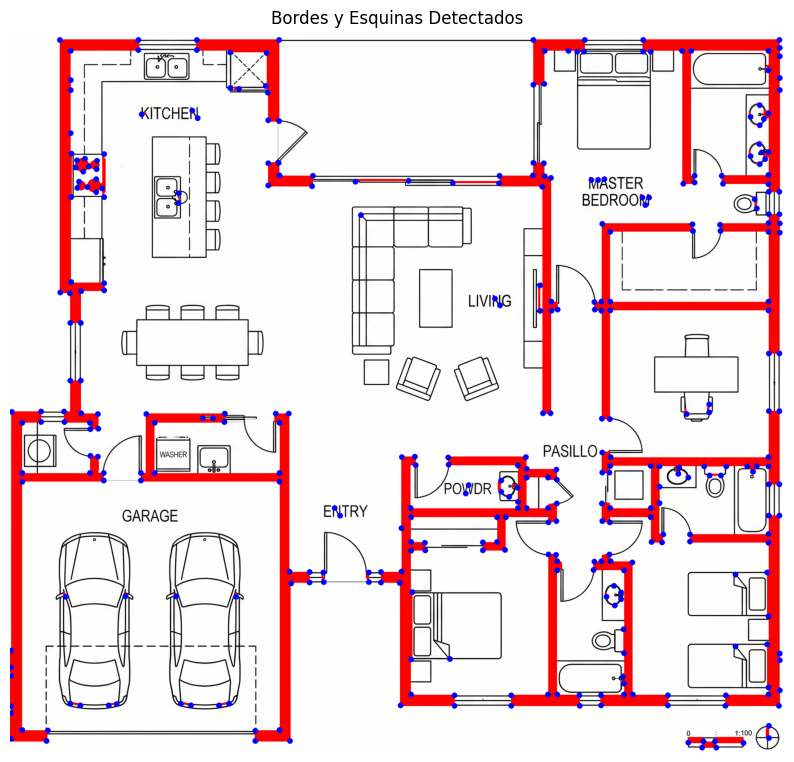

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Clase para tener limpio el codigo principal y sea mas sencillo de usar en el repositorio de la libreria
class ProcesadorPlanos:
    #Primero mandamos a llamar la imagen y la guardamos en una variable de clase para poder usarla
    def __init__(self, ruta_imagen):
        self.imagen = cv2.imread(ruta_imagen)
        #Codicionamos a que la encuentre en caso de que no se encuentre mandamos un mensaje de error
        if self.imagen is None:
            raise ValueError("No se pudo cargar la imagen.")
        self.resultado = self.imagen.copy()

    #Aplicames la escala de grises asi es mas facil trabajar con la imagen y aplicar los filtros necesarios
    def aplicar_escala_grises(self, img=None):
        #A diferencia de lo visto en clases pasamos la imagen mas abajo, esto le da la libertad de tener un script limpio y un codigo mas universal donde el usuario no necesite meter mano
        target = img if img is not None else self.imagen
        return cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)

    #Aplicamos un filtro bilateral para preservar los bordes, esto es importante para no perder detalles importantes de la imagen, a diferencia del gaussiano que puede difuminar los bordes, 
    #el bilateral es mas efectivo para este tipo de imagenes donde los bordes son cruciales
    def aplicar_filtrado(self, gris):
        #Los parametros del filtro bilateral pueden ser ajustados dependiendo de la calidad de la imagen, pero en general estos valores que encontramos funcionan bien para planos arquitectonicos
        return cv2.bilateralFilter(gris, 9, 75, 75)

    "Seguimos con corregir la inclinacion, aqui es donde aplicamos la transformacion afin y la transformada de hough para detectar las lineas"
    "y corregir la inclinacion de la imagen, esto es crucial para que los siguientes pasos funcionen correctamente"
    
    #Para evitar lineas inclinadas o planos que tengan una inclinacion, aplicamos una transformacion afin basada en la transformada de hough para detectar las lineas principales y corregir 
    # la inclinacion de la imagen, esto es importante para que los siguientes pasos funcionen correctamente y no tengamos lineas inclinadas que puedan afectar la deteccion de muros y esquinas 
    # o directamente afectar la visualizacion final"
    def corregir_inclinacion(self, gris):
        # Deteccion de bordes con Canny para mejorar la deteccion de lineas y pasarselas a Hough
        bordes = cv2.Canny(gris, 50, 150)
        # Hough en este punto nos ayuda a detectar las lineas principales del plano, lo que nos permite calcular el ángulo de inclinacion y corregirlo con una transformacion
        lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)
        
        #Este es solo para la correccion de inclinacion, calculamos el angulo de cada linea detectada y tomamos la mediana para corregir la inclinacion de la imagen, se usa la formula de 
        # atan2 para calcular el angulo de inclinacion de cada linea, y luego se toma la mediana de esos angulos para obtener un valor representativo de la inclinacion general del plano

        angulo_final = 0
        if lineas is not None:
            angulos = []
            for l in lineas:
                x1, y1, x2, y2 = l[0]
                ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
                if abs(ang) < 45: angulos.append(ang)
            if angulos: angulo_final = np.median(angulos)

        #Aqui pasamos a la matriz de rotacion que corrige la inclinacion de la imagen, se calcula el centro de la imagen y se aplica una rotacion basada en el angulo calculado anteriormente, 
        # esto nos da una imagen corregida sin inclinacion en lineas ya que el plano necesita estar lo mas recto posible para que los siguientes pasos funcionen correctamente, 
        # ademas de mejorar la visualizacion final

        #Aqui detectamos el ancho y alto de la imagen para calcular el centro
        height, width = gris.shape[:2]
        centro = (width // 2, height // 2)
        #El 1.0 es el factor de escala, en este caso no queremos escalar la imagen, solo rotarla, por lo que dejamos el factor de escala en 1
        Matriz = cv2.getRotationMatrix2D(centro, angulo_final, 1.0)
        self.resultado = cv2.warpAffine(self.imagen, Matriz, (width, height))
        return cv2.cvtColor(self.resultado, cv2.COLOR_BGR2GRAY)

        #Aplicamos una umbralizacion simple para obtener una imagen binaria, esto es importante para poder aplicar la morfologia y aislar los muros, ademas de facilitar la deteccion de bordes y esquinas
        #usando la funcion de umbralizacion de opencv, con un umbral de 200, esto puede ser ajustado dependiendo de la calidad de la imagen, pero en general este valor funciona bien para planos arquitectonicos,
        #porque los muros suelen ser de un color oscuro y el fondo suele ser claro, por lo que un umbral de 200 nos ayuda a separar los muros del fondo
    def aplicar_umbralizacion(self, gris):
        _, binaria = cv2.threshold(gris, 200, 255, cv2.THRESH_BINARY_INV)
        return binaria
    
        #Ahora con esta mascara, discriminamos los muros de las cotas y muebles finos, aplicando una operacion de apertura para eliminar las lineas finas, y luego una operacion de cierre para rellenar 
        # los huecos que puedan quedar en los muros, esto nos da una mascara mas limpia y solida de los muros, lo que facilita la deteccion de bordes.
        #El rellenar ayuda de que no queden huecos en los muros que puedan afectar la deteccion o que se hagan segmentaciones erroneas en los muros
    def aislar_muros(self, binaria):
        kernel = np.ones((5, 5), np.uint8)
        mascara = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel)
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
        return mascara
    
        #Vamos con la parte de detectar bordes y esquinas, para esto aplicamos el detector de bordes de Canny sobre la mascara de muros, esto nos da una imagen con los bordes de los muros, lo que facilita 
        # la deteccion de esquinas, luego aplicamos el detector de esquinas de Shi-Tomasi sobre la mascara de muros, esto nos da las esquinas de los muros, lo que es importante para la visualizacion final 
        # y para tener una mejor representacion de la estructura del plano. Se uso Shi-Tomasi porque es un detector de esquinas mas robusto y preciso que el de Harris (Ya que por mas movimientos usados podia relativamente
        # quear bien pero busca parametros especificos que hacen que no sea unversal), lo que es importante para procesar planos de alta resolucion sin que el tiempo de procesamiento sea excesivo
    def detectar_caracteristicas(self, mascara):
        # Bordes de Canny sobre la mascara de muros
        bordes = cv2.Canny(mascara, 50, 150)
        # Esquinas (Shi-Tomasi) los valores de maxCorners, qualityLevel y minDistance pueden ser ajustados dependiendo de la calidad de la imagen, pero en general estos valores funcionan bien para los planos
        esquinas = cv2.goodFeaturesToTrack(mascara, 500, 0.01, 15)
        return bordes, esquinas

        #Finalmente, marcamos visualmente los resultados, pintando los muros de rojo y las esquinas de azul, esto nos da una visualizacion clara y facil de entender de la estructura del plano, ademas de resaltar los elementos
        #  importantes como los muros y las esquinas, lo que es crucial para la interpretacion del plano por parte del usuario
    def marcar_visual(self, mascara, esquinas):
        # Pintar muros de rojo
        self.resultado[mascara == 255] = [0, 0, 255]
        # Pintar esquinas de azul
        #Conddicionamos a que haya esquinas detectadas para evitar errores, y luego iteramos sobre las esquinas para dibujar un circulo azul en cada una de ellas
        if esquinas is not None:
            for i in esquinas.astype(int):
                x, y = i.ravel()
                cv2.circle(self.resultado, (x, y), 7, (255, 0, 0), -1)

        #Para terminar una funcion final para ejecutar todo el procesamiento, esto hace que el codigo principal sea mas limpio y facil de usar, ademas de permitir que el usuario pueda usar cada parte 
        #de forma independiente si lo desea
    def ejecutar(self):
        gris = self.aplicar_escala_grises()
        filtrado = self.aplicar_filtrado(gris)
        gris_recto = self.corregir_inclinacion(filtrado) 
        binaria = self.aplicar_umbralizacion(gris_recto)
        mascara = self.aislar_muros(binaria)
        bordes, esquinas = self.detectar_caracteristicas(mascara)
        self.marcar_visual(mascara, esquinas)
        
        return self.resultado

if __name__ == "__main__":
    procesador = ProcesadorPlanos("Plano_4.png")
    final = procesador.ejecutar()
    
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
    plt.title("Bordes y Esquinas Detectados")
    plt.axis('off')
    plt.show()